In [192]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GroupShuffleSplit

In [193]:
# CSV Master (path to be adjusted accordingly)
#file_path = "../raw_data/xgboost_features_6s_10kHz_compressed_after_normalization.csv"
#file_path = "../raw_data/xgboost_features_6s_10kHz_compression_before_normalization.csv"
#file_path = "../raw_data/xgboost_features_6s_10kHz_compressed_after_normalization_w_overlapping.csv"
#file_path = "../raw_data/xgboost_features_6s_10kHz_compression_before_normalization_w_overlapping.csv"
#file_path = "../raw_data/xgboost_features_6s_10kHz_compressed_after_normalization_w_overlapping_mfcc15.csv"
file_path = "../raw_data/xgboost_features_6s_12kHz_compressed_after_normalization_w_overlapping_mfcc15.csv"



if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"done! {len(df)} lines")
    
    # check NaNs
    nans = df.isnull().sum().sum()
    print(f"missing values: {nans}")
    
    # columns
    print(f"cols: {df.columns.tolist()}")
    display(df.head())
else:
    print("check path")

done! 3606 lines
missing values: 0
cols: ['rms_mean', 'rms_std', 'zcr_mean', 'centroid_mean', 'centroid_std', 'flatness_mean', 'flatness_std', 'rolloff_mean', 'flux_mean', 'bandwidth_mean', 'skewness_mean', 'kurtosis_mean', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_14_mean', 'mfcc_14_std', 'mfcc_15_mean', 'mfcc_15_std', 'patient_id', 'chunk_id', 'original_file', 'diagnosis']


,rms_mean,rms_std,zcr_mean,centroid_mean,centroid_std,flatness_mean,flatness_std,rolloff_mean,flux_mean,bandwidth_mean,...,mfcc_13_mean,mfcc_13_std,mfcc_14_mean,mfcc_14_std,mfcc_15_mean,mfcc_15_std,patient_id,chunk_id,original_file,diagnosis
0,0.740132,0.083106,0.001316,98.066230,93.868556,0.000034,0.000146,119.431516,1.826715,340.148743,...,8.284259,2.947182,8.153688,3.566122,7.156815,3.025179,223,0,223_1b1_Pr_sc_Meditron.wav,COPD
1,0.696974,0.079933,0.001572,94.479942,81.417895,0.000041,0.000361,107.338763,1.494651,338.655438,...,8.452517,3.363525,7.557367,4.090311,6.353885,4.028513,223,1,223_1b1_Pr_sc_Meditron.wav,COPD
2,0.670958,0.079359,0.001590,90.514388,75.801911,0.000024,0.000205,99.817154,1.613105,339.537651,...,8.950355,2.893862,7.780566,3.040372,6.503709,3.147859,223,2,223_1b1_Pr_sc_Meditron.wav,COPD
3,0.675636,0.093185,0.001153,81.297469,52.764923,0.000008,0.000023,81.740359,1.693879,322.028853,...,8.722843,2.706289,8.697692,3.737317,6.902027,3.432181,223,3,223_1b1_Pr_sc_Meditron.wav,COPD
4,0.635533,0.069224,0.001202,80.768717,67.285689,0.000014,0.000083,81.865027,1.705645,325.092538,...,9.458111,3.485257,10.628664,4.948114,8.951859,4.647463,223,4,223_1b1_Pr_sc_Meditron.wav,COPD


In [194]:
if 'diagnosis' in df.columns:
    print("diagnosis is in df")
    print(df['diagnosis'].value_counts())
    df_final = df.copy() # original
else:
    print("'diagnosis' was not found in the csv")

diagnosis is in df
diagnosis
COPD              2597
Pneumonia          296
Healthy            275
URTI               182
Bronchiectasis     128
Bronchiolitis      104
LRTI                16
Asthma               8
Name: count, dtype: int64


In [195]:
# Drop Asthma and LRTI + 'Bronchiolitis' (maybe)

classes_to_keep = ['COPD', 'Pneumonia', 'Healthy', 'URTI', 'Bronchiectasis']

# Filter df
df_filtered = df[df['diagnosis'].isin(classes_to_keep)].copy()

print(f"original dataset: {len(df)} lines")
print(f"filtered one: {len(df_filtered)} lines")
print(f"\nnew dist:\n{df_filtered['diagnosis'].value_counts()}")

original dataset: 3606 lines
filtered one: 3478 lines

new dist:
diagnosis
COPD              2597
Pneumonia          296
Healthy            275
URTI               182
Bronchiectasis     128
Name: count, dtype: int64


In [196]:
#crazy class imbalance. make XGboost ready:

In [197]:
#as diogo said: goldfish memory
print(df_filtered.columns.tolist())

['rms_mean', 'rms_std', 'zcr_mean', 'centroid_mean', 'centroid_std', 'flatness_mean', 'flatness_std', 'rolloff_mean', 'flux_mean', 'bandwidth_mean', 'skewness_mean', 'kurtosis_mean', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_14_mean', 'mfcc_14_std', 'mfcc_15_mean', 'mfcc_15_std', 'patient_id', 'chunk_id', 'original_file', 'diagnosis']


In [206]:
# filter and clean
# avoid label gaps # removed 'Bronchiolitis' for now
classes_to_keep = ['COPD', 'Pneumonia', 'Healthy', 'URTI', 'Bronchiectasis']
df_filtered = df_final[df_final['diagnosis'].isin(classes_to_keep)].copy()
df_filtered = df_filtered.reset_index(drop=True)

# encode - sequentially (0, 1, 2...) ONLY!!! on the filtered data
le_final = LabelEncoder()
df_filtered['target'] = le_final.fit_transform(df_filtered['diagnosis'])

mapping = dict(zip(le_final.classes_, le_final.transform(le_final.classes_)))
print(f"Class mapping: {mapping}")

# define X (features), y (target) and groups 
cols_to_drop = ['original_file', 'patient_id', 'diagnosis', 'target', 'chunk_id']
X = df_filtered.drop(columns=[c for c in cols_to_drop if c in df_filtered.columns])
y = df_filtered['target']
groups = df_filtered['patient_id']

print(f"Features: {X.shape[1]} columns | Samples: {len(X)}")

# training loop
gkf = GroupKFold(n_splits=3) # try 5
fold = 1

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    # split data
    X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]

    groups_train_full = groups.iloc[train_idx] #

    #second split
    gss_val = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

    #index inside X_train_full
    idx_train, idx_val = next(gss_val.split(X_train_full, y_train_full, groups_train_full))

    X_train, X_val = X_train_full.iloc[idx_train], X_train_full.iloc[idx_val]
    y_train, y_val = y_train_full.iloc[idx_train], y_train_full.iloc[idx_val]
    
    # calculate weights - for imbalance (only for new xtrain)
    w_train = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # XGBoost w the correct num of classes
    model = xgb.XGBClassifier(
        n_estimators=600, # increase? originally 100
        #learning_rate=0.5, # 0.1 or 0.05? # comment cell as well
        max_depth=3, # decrease to 3, originally 6
        # new try
        subsample=0.8,        # only 80% of lines in each tree
        colsample_bytree=0.7, # only 70% of cols in each tree
        reg_lambda=1.5,       
        #
        objective='multi:softprob',
        num_class=len(le_final.classes_),
        random_state=42,
        eval_metric='mlogloss',
        early_stopping_rounds=15 # define an early stopping? 10?
    )
    
    # train
    model.fit(
        X_train, y_train, 
        sample_weight=w_train,
        eval_set=[(X_val, y_val)], # ,monitor validation set
        verbose=False
    )

    # predict
    y_pred = model.predict(X_test)
    score = model.score(X_test, y_test)
    
    print(f"\n--- fold {fold} | acc: {score:.4f} ---")

    # dynamic target names for the classification report
    present_labels = np.unique(y_test)
    target_names = [le_final.classes_[i] for i in present_labels]

    print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names))
    
    fold += 1

Class mapping: {'Bronchiectasis': np.int64(0), 'COPD': np.int64(1), 'Healthy': np.int64(2), 'Pneumonia': np.int64(3), 'URTI': np.int64(4)}
Features: 42 columns | Samples: 3478

--- fold 1 | acc: 0.8491 ---
                precision    recall  f1-score   support

Bronchiectasis       0.71      0.95      0.81        56
          COPD       0.98      0.92      0.95       937
       Healthy       0.37      0.48      0.41        71
     Pneumonia       0.33      0.75      0.46        32
          URTI       0.26      0.16      0.19        64

      accuracy                           0.85      1160
     macro avg       0.53      0.65      0.57      1160
  weighted avg       0.87      0.85      0.86      1160


--- fold 2 | acc: 0.7627 ---
                precision    recall  f1-score   support

Bronchiectasis       0.42      0.20      0.27        40
          COPD       0.84      0.94      0.89       810
       Healthy       0.53      0.65      0.58        86
     Pneumonia       0.60      0

<Figure size 1000x800 with 0 Axes>

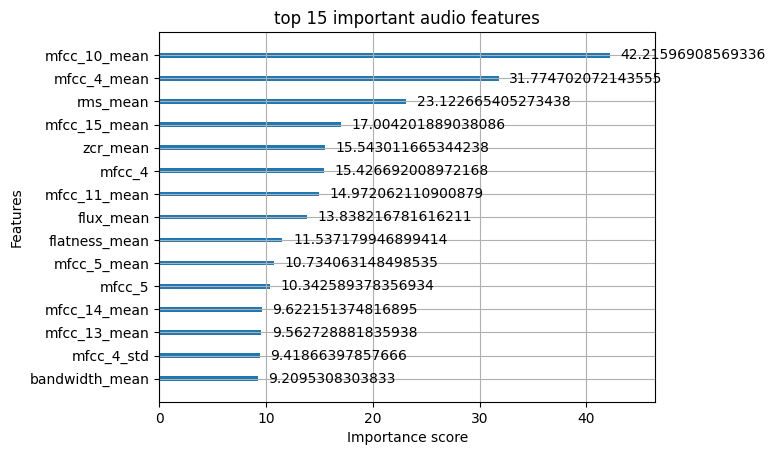

In [189]:
# feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('top 15 important audio features')
plt.show()


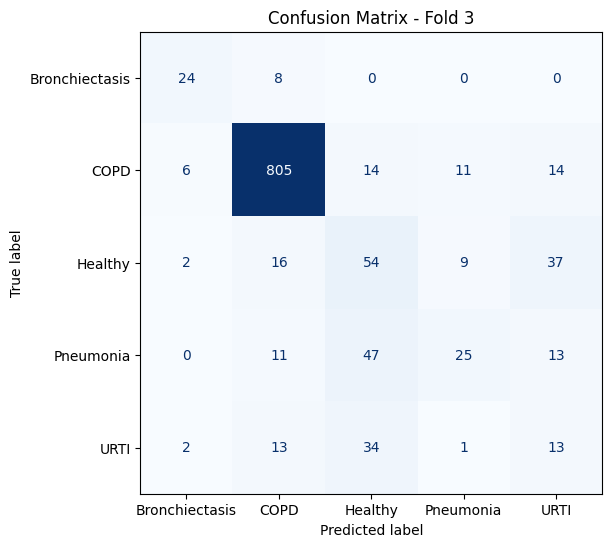

In [165]:
from sklearn.metrics import ConfusionMatrixDisplay

# confusion matrix - where the model is failing
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=le_final.classes_, 
    cmap='Blues', 
    ax=ax,
    colorbar=False
)
plt.title(f"Confusion Matrix - Fold {fold-1}")
plt.show()